# 수면(Water) 세그멘테이션 모델 학습 — Roboflow COCO Segmentation → YOLO-seg

Roboflow에서 내보낸 **COCO Segmentation** 데이터셋(water-ypkpr, 1 class = `water`)으로
수면 영역을 픽셀 단위로 검출하는 인스턴스 세그멘테이션 모델을 학습합니다.

**파이프라인**
1. COCO RLE 마스크 디코딩 → 외곽선(contour) → 정규화 폴리곤
2. YOLO-seg 라벨(`.txt`) + `data.yaml` 생성
3. YOLO 세그멘테이션 모델 파인튜닝
4. 검증(mask mAP) + 시각화
5. 침수 파이프라인 연동 유틸 (수면 상단 y좌표 / 바퀴 bbox 침수율)

> 이 데이터셋의 `segmentation` 필드는 **폴리곤이 아니라 압축 RLE**(`{"counts": "...", "size": [h,w]}`)입니다.
> Ultralytics가 직접 읽지 못하므로 아래 3번 셀의 변환 과정이 필수입니다.

## 1. 설치 및 환경 확인

In [1]:
# 최초 1회만 실행 (이미 설치되어 있으면 건너뛰세요)
# !pip install ultralytics opencv-python numpy pyyaml matplotlib tqdm

In [2]:
import os, sys, json, shutil, random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
import torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

try:
    import ultralytics
    print("Ultralytics:", ultralytics.__version__)
except ImportError:
    print("[!] ultralytics 미설치 → 위 셀의 pip install 실행 필요")

Python : 3.11.9
PyTorch: 2.12.0.dev20260408+cu128
CUDA   : True | NVIDIA GeForce RTX 5060 Laptop GPU
Ultralytics: 8.4.86


## 2. 경로 설정 (여기만 수정하면 됩니다)

In [3]:
CFG = {
    # Roboflow에서 내려받아 압축 해제한 폴더 (train / valid / test 하위폴더가 있는 곳)
    "SRC_ROOT": r"C:\Project\PythonProject\PyTorch001\datasets\water_raw",

    # 변환된 YOLO 형식 데이터셋이 저장될 위치
    "DST_ROOT": r"C:\Project\PythonProject\PyTorch001\datasets\water_seg",

    # 학습 결과 저장 위치
    "RUN_PROJECT": r"C:\Project\PythonProject\PyTorch001\runs_water",
    "RUN_NAME": "water_seg_v1",

    # 하이퍼파라미터 (RTX 5060 Laptop 8GB 기준)
    "MODEL": "yolo26n-seg.pt",  # 폴백: yolo11n-seg -> yolov8n-seg / 상향: yolo26s-seg
    "IMGSZ": 640,
    "EPOCHS": 100,
    "BATCH": 8,

    # 폴리곤 변환 파라미터
    "MIN_AREA_RATIO": 0.0005,   # 이미지 면적 대비 이보다 작은 조각은 노이즈로 제거
    "APPROX_EPS_RATIO": 0.002,  # 클수록 폴리곤 점 개수 감소(단순화)
}

SRC_ROOT = Path(CFG["SRC_ROOT"])
DST_ROOT = Path(CFG["DST_ROOT"])
SPLITS = ["train", "valid", "test"]

# 원본 폴더 구조 확인
assert SRC_ROOT.exists(), f"경로 없음: {SRC_ROOT}"
for s in SPLITS:
    p = SRC_ROOT / s / "_annotations.coco.json"
    n_img = len(list((SRC_ROOT / s).glob("*.jpg"))) if (SRC_ROOT / s).exists() else 0
    print(f"{s:6s} | json={p.exists()} | images={n_img}")

train  | json=True | images=421
valid  | json=True | images=92
test   | json=True | images=54


### 2-1. 사전 점검 — 다운로드가 온전한지 먼저 확인

변환을 돌리기 전에 JSON과 실제 파일 개수가 맞는지 대조합니다.
`JSON 이미지 수 == 디스크 JPG 수` 여야 하고, 3개 split 합계가 README에 적힌 총 장수와 같아야 합니다.

In [4]:
total_img = total_ann = 0
for split in SPLITS:
    d = SRC_ROOT / split
    j = d / "_annotations.coco.json"
    if not j.exists():
        print(f"{split:6s} | [!] JSON 없음"); continue
    coco = json.loads(j.read_text(encoding="utf-8"))
    n_json = len(coco["images"])
    n_disk = len(list(d.glob("*.jpg")))
    with_ann = len({a["image_id"] for a in coco["annotations"]})
    flag = "OK " if n_json == n_disk else "MISMATCH"
    print(f"{split:6s} | {flag} | JSON {n_json:4d} / 디스크 {n_disk:4d} | "
          f"라벨있음 {with_ann:4d} | 어노 {len(coco['annotations']):4d}")
    total_img += n_json; total_ann += len(coco["annotations"])

print(f"\n합계: 이미지 {total_img} / 어노테이션 {total_ann}")
print("→ README.roboflow.txt 에 적힌 장수와 일치하는지 확인하세요")

train  | OK  | JSON  421 / 디스크  421 | 라벨있음  421 | 어노  519
valid  | OK  | JSON   92 / 디스크   92 | 라벨있음   91 | 어노  102
test   | OK  | JSON   54 / 디스크   54 | 라벨있음   54 | 어노   63

합계: 이미지 567 / 어노테이션 684
→ README.roboflow.txt 에 적힌 장수와 일치하는지 확인하세요


## 3. COCO RLE → 폴리곤 변환 유틸

`pycocotools`가 설치되어 있으면 그것을 쓰고, 없으면 **순수 파이썬 RLE 디코더**로 대체합니다.
(Windows에서 `pycocotools` 빌드가 자주 실패하므로 의존성 없이 동작하도록 구성했습니다.)

In [5]:
def _rle_decode_py(counts_str, size):
    '''압축 COCO RLE 문자열 → (H, W) uint8 바이너리 마스크. pycocotools 없이 동작.'''
    h, w = size
    cnts, m, p = [], 0, 0
    while p < len(counts_str):
        x, k, more = 0, 0, 1
        while more:
            c = ord(counts_str[p]) - 48
            x |= (c & 0x1F) << (5 * k)
            more = c & 0x20
            p += 1
            k += 1
            if not more and (c & 0x10):
                x |= (-1 << (5 * k))
        if m > 2:
            x += cnts[m - 2]
        cnts.append(x)
        m += 1

    flat = np.zeros(h * w, dtype=np.uint8)
    idx, val = 0, 0
    for c in cnts:
        flat[idx:idx + c] = val
        idx += c
        val ^= 1
    return flat.reshape((w, h)).T  # COCO RLE은 column-major


try:
    from pycocotools import mask as _maskutil
    def rle_to_mask(seg):
        s = {"counts": seg["counts"].encode() if isinstance(seg["counts"], str) else seg["counts"],
             "size": seg["size"]}
        return _maskutil.decode(s).astype(np.uint8)
    print("RLE 디코더: pycocotools")
except ImportError:
    def rle_to_mask(seg):
        return _rle_decode_py(seg["counts"], seg["size"])
    print("RLE 디코더: 순수 파이썬 (fallback)")


def seg_to_polygons(seg, h, w, min_area_ratio, eps_ratio):
    '''COCO segmentation(RLE 또는 폴리곤 리스트) → [[x1,y1,x2,y2,...], ...] 픽셀 좌표 폴리곤.'''
    # 이미 폴리곤 형식인 경우 그대로 반환
    if isinstance(seg, list):
        return [list(map(float, p)) for p in seg if len(p) >= 6]

    mask = rle_to_mask(seg)
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_area = min_area_ratio * h * w
    polys = []
    for c in contours:
        if cv2.contourArea(c) < min_area:
            continue
        approx = cv2.approxPolyDP(c, eps_ratio * cv2.arcLength(c, True), True)
        if len(approx) < 3:
            continue
        polys.append(approx.reshape(-1).astype(float).tolist())
    return polys


def safe_link(src: Path, dst: Path):
    '''Windows 심볼릭 링크 권한 문제(WinError 1314) 회피: 하드링크 → 실패 시 복사.'''
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except Exception:
        shutil.copy2(src, dst)

RLE 디코더: 순수 파이썬 (fallback)


## 4. 변환 실행 — YOLO 세그멘테이션 데이터셋 생성

In [6]:
def convert_split(split: str) -> dict:
    src_dir = SRC_ROOT / split
    ann_path = src_dir / "_annotations.coco.json"
    if not ann_path.exists():
        print(f"[skip] {split}: annotation 파일 없음")
        return {}

    img_out = DST_ROOT / "images" / split
    lbl_out = DST_ROOT / "labels" / split
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    coco = json.loads(ann_path.read_text(encoding="utf-8"))

    # Roboflow는 supercategory='none'인 더미 카테고리(id=0)를 넣습니다 → 제외 후 0부터 재매핑
    real_cats = [c for c in coco["categories"] if c.get("supercategory") != "none"]
    if not real_cats:
        real_cats = coco["categories"]
    cat2cls = {c["id"]: i for i, c in enumerate(sorted(real_cats, key=lambda x: x["id"]))}
    names = [c["name"] for c in sorted(real_cats, key=lambda x: x["id"])]

    anns_by_img = defaultdict(list)
    for a in coco["annotations"]:
        anns_by_img[a["image_id"]].append(a)

    stat = Counter()
    for im in coco["images"]:
        src_img = src_dir / im["file_name"]
        if not src_img.exists():
            stat["missing_image"] += 1
            continue

        h, w = im["height"], im["width"]
        lines = []
        for a in anns_by_img.get(im["id"], []):
            if a["category_id"] not in cat2cls:
                continue
            polys = seg_to_polygons(a["segmentation"], h, w,
                                    CFG["MIN_AREA_RATIO"], CFG["APPROX_EPS_RATIO"])
            if not polys:
                stat["empty_poly"] += 1
                continue
            cls = cat2cls[a["category_id"]]
            for p in polys:
                # 정규화 + [0,1] 클리핑
                norm = []
                for i in range(0, len(p), 2):
                    norm.append(min(max(p[i] / w, 0.0), 1.0))
                    norm.append(min(max(p[i + 1] / h, 0.0), 1.0))
                lines.append(str(cls) + " " + " ".join(f"{v:.6f}" for v in norm))
                stat["polygons"] += 1

        safe_link(src_img, img_out / im["file_name"])
        (lbl_out / (Path(im["file_name"]).stem + ".txt")).write_text("\n".join(lines), encoding="utf-8")
        stat["images"] += 1
        if not lines:
            stat["background_only"] += 1

    print(f"[{split}] {dict(stat)} | classes={names}")
    return {"names": names, "stat": stat}


DST_ROOT.mkdir(parents=True, exist_ok=True)
results_meta = {s: convert_split(s) for s in SPLITS}
CLASS_NAMES = next((m["names"] for m in results_meta.values() if m), ["water"])
print("\n최종 클래스:", CLASS_NAMES)

[train] {'polygons': 928, 'images': 421} | classes=['water']
[valid] {'polygons': 132, 'images': 92, 'background_only': 1} | classes=['water']
[test] {'polygons': 107, 'images': 54} | classes=['water']

최종 클래스: ['water']


## 5. 변환 검증 — 라벨을 이미지 위에 다시 그려보기

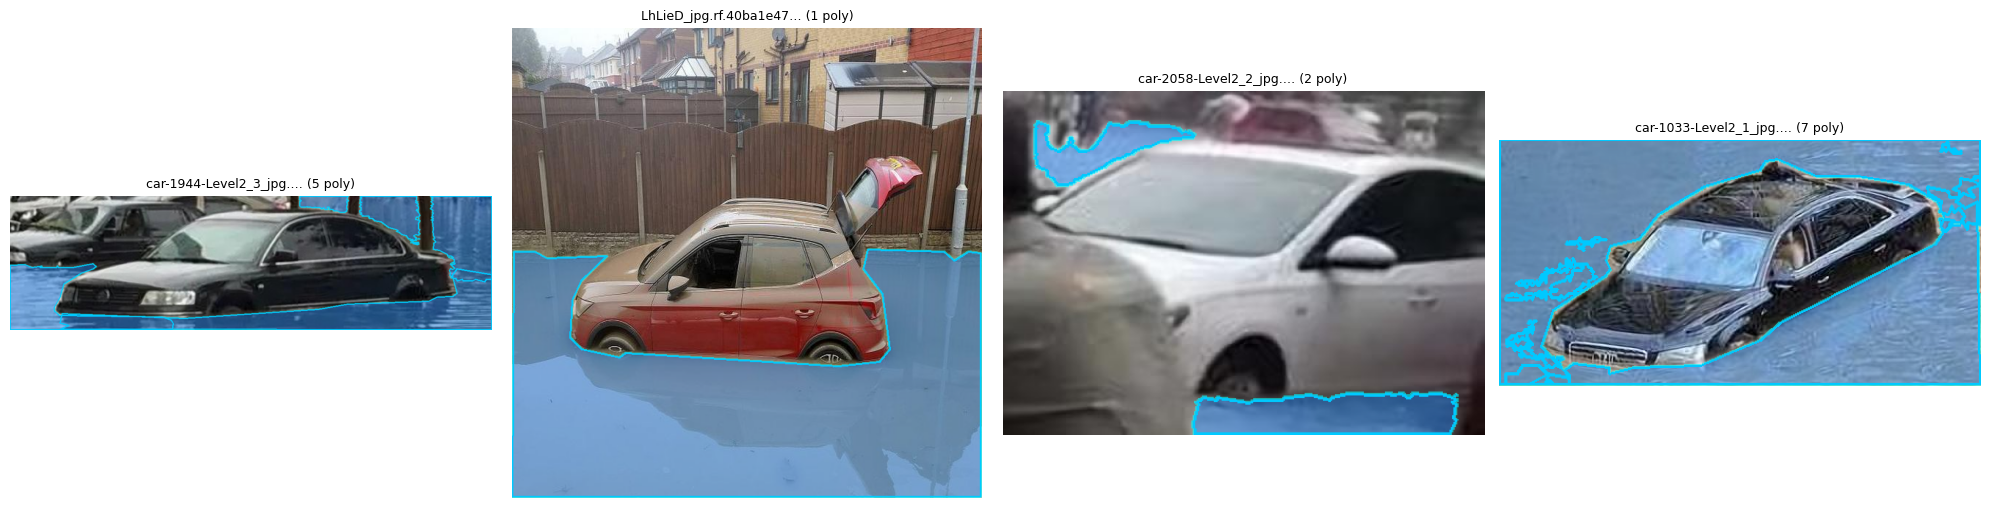

In [7]:
import matplotlib.pyplot as plt

def preview(split="train", n=4, seed=0):
    img_dir = DST_ROOT / "images" / split
    lbl_dir = DST_ROOT / "labels" / split
    files = sorted(img_dir.glob("*.jpg"))
    if not files:
        print("이미지 없음"); return
    random.seed(seed)
    picks = random.sample(files, min(n, len(files)))

    fig, axes = plt.subplots(1, len(picks), figsize=(5 * len(picks), 5))
    axes = np.atleast_1d(axes)
    for ax, f in zip(axes, picks):
        img = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        overlay = img.copy()
        lbl = lbl_dir / (f.stem + ".txt")
        n_poly = 0
        if lbl.exists():
            for line in lbl.read_text(encoding="utf-8").splitlines():
                v = line.split()
                if len(v) < 7:
                    continue
                pts = np.array(list(map(float, v[1:])), dtype=np.float32).reshape(-1, 2)
                pts[:, 0] *= w; pts[:, 1] *= h
                cv2.fillPoly(overlay, [pts.astype(np.int32)], (0, 120, 255))
                cv2.polylines(img, [pts.astype(np.int32)], True, (0, 255, 255), 2)
                n_poly += 1
        blended = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)
        ax.imshow(blended); ax.set_title(f"{f.name[:22]}… ({n_poly} poly)", fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()

preview("train", n=4)

## 6. `data.yaml` 생성

In [8]:
import yaml

data_yaml = {
    "path": str(DST_ROOT),
    "train": "images/train",
    "val": "images/valid",
    "test": "images/test",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}

YAML_PATH = DST_ROOT / "data.yaml"
YAML_PATH.write_text(yaml.safe_dump(data_yaml, allow_unicode=True, sort_keys=False), encoding="utf-8")
print(YAML_PATH.read_text(encoding="utf-8"))

path: C:\Project\PythonProject\PyTorch001\datasets\water_seg
train: images/train
val: images/valid
test: images/test
names:
  0: water



## 7. 학습

- `yolo11n-seg.pt`(nano)로 시작 — 8GB VRAM에서 batch 8 / 640px 여유 있게 동작합니다.
- OOM이 나면 `BATCH`를 4로, 그래도 안 되면 `IMGSZ`를 512로 낮추세요.
- 수면은 형태 변화가 크고 반사·그림자 영향을 받으므로 **색상 증강(hsv)** 은 유지하고,
  좌우 반전은 켜되 **상하 반전(flipud)은 0** 으로 둡니다(수면은 항상 아래쪽에 있음).

In [9]:
from ultralytics import YOLO

def load_model(preferred):
    # ultralytics 버전에 따라 yolo26 가중치가 없을 수 있으므로 순차 폴백
    candidates = [preferred, "yolo11n-seg.pt", "yolov8n-seg.pt"]
    seen = set()
    for name in candidates:
        if name in seen:
            continue
        seen.add(name)
        try:
            m = YOLO(name)
            print(f"[OK] 모델 로드: {name}")
            return m, name
        except Exception as e:
            print(f"[skip] {name} 실패 → {type(e).__name__}: {str(e)[:120]}")
    raise RuntimeError("사용 가능한 세그멘테이션 가중치를 찾지 못했습니다.")

model, USED_MODEL = load_model(CFG["MODEL"])

results = model.train(
    data=str(YAML_PATH),
    epochs=CFG["EPOCHS"],
    imgsz=CFG["IMGSZ"],
    batch=CFG["BATCH"],
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2,              # Windows에서는 2 이하 권장
    project=CFG["RUN_PROJECT"],
    name=CFG["RUN_NAME"],
    exist_ok=True,
    patience=30,
    optimizer="auto",
    cos_lr=True,
    # 증강
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=0.0, translate=0.1, scale=0.4, shear=0.0,
    fliplr=0.5, flipud=0.0, mosaic=1.0, close_mosaic=10,
    val=True, plots=True, seed=42,
)

# Ultralytics는 project 인자와 무관하게 경로를 중첩시키는 경우가 있으므로 실제 경로를 읽습니다
SAVE_DIR = Path(results.save_dir)
BEST_PT = SAVE_DIR / "weights" / "best.pt"
print("사용 모델:", USED_MODEL)
print("저장 경로:", SAVE_DIR)
print("best.pt  :", BEST_PT, "| exists:", BEST_PT.exists())

[OK] 모델 로드: yolo26n-seg.pt
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Project\PythonProject\PyTorch001\datasets\water_seg\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\polars\meta\build.py:5: UserWarning: Polars binary is missing!
  from polars._utils.polars_version import get_polars_version


Plotting labels to C:\Project\PythonProject\PyTorch001\runs_water\water_seg_v1\labels.jpg... 
WARNING name 'PySeries' is not defined
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to C:\Project\PythonProject\PyTorch001\runs_water\water_seg_v1
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      1/100      1.83G      1.327       3.35      4.571    0.01665        4.3         27        640: 100% ━━━━━━━━━━━━ 53/53 1.9it/s 27.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.6s/it 15.6s3.0s
                   all         92        132    0.00402      0.841      0.139     0.0517    0.00362      0.758      0.118     0.0438

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      2/100      2.16G      1.244      2.

## 8. 검증 — mask mAP 확인

In [10]:
best = YOLO(str(BEST_PT))

# validation set
m_val = best.val(data=str(YAML_PATH), split="val", imgsz=CFG["IMGSZ"], device=0 if torch.cuda.is_available() else "cpu")
print("\n[VAL]  Box mAP50: %.4f | mAP50-95: %.4f" % (m_val.box.map50, m_val.box.map))
print("[VAL] Mask mAP50: %.4f | mAP50-95: %.4f" % (m_val.seg.map50, m_val.seg.map))

# test set
try:
    m_test = best.val(data=str(YAML_PATH), split="test", imgsz=CFG["IMGSZ"], device=0 if torch.cuda.is_available() else "cpu")
    print("\n[TEST] Mask mAP50: %.4f | mAP50-95: %.4f" % (m_test.seg.map50, m_test.seg.map))
except Exception as e:
    print("[test 스킵]", e)

Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 283.7231.9 MB/s, size: 48.1 KB)
val: Scanning C:\Project\PythonProject\PyTorch001\datasets\water_seg\labels\valid.cache... 92 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.8it/s 1.6s0.3s
                   all         92        132      0.821      0.659      0.755      0.592      0.741      0.673       0.72      0.518
Speed: 1.5ms preprocess, 7.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Project\PythonProject\PyTorch001\final_project\runs\segment\val

[VAL]  Box mAP50: 0.7546 | mAP50-95: 0.5917
[VAL] Mask mAP50: 0.7202 | mAP50-95: 0.5

==================== confusion_matrix_normalized.png


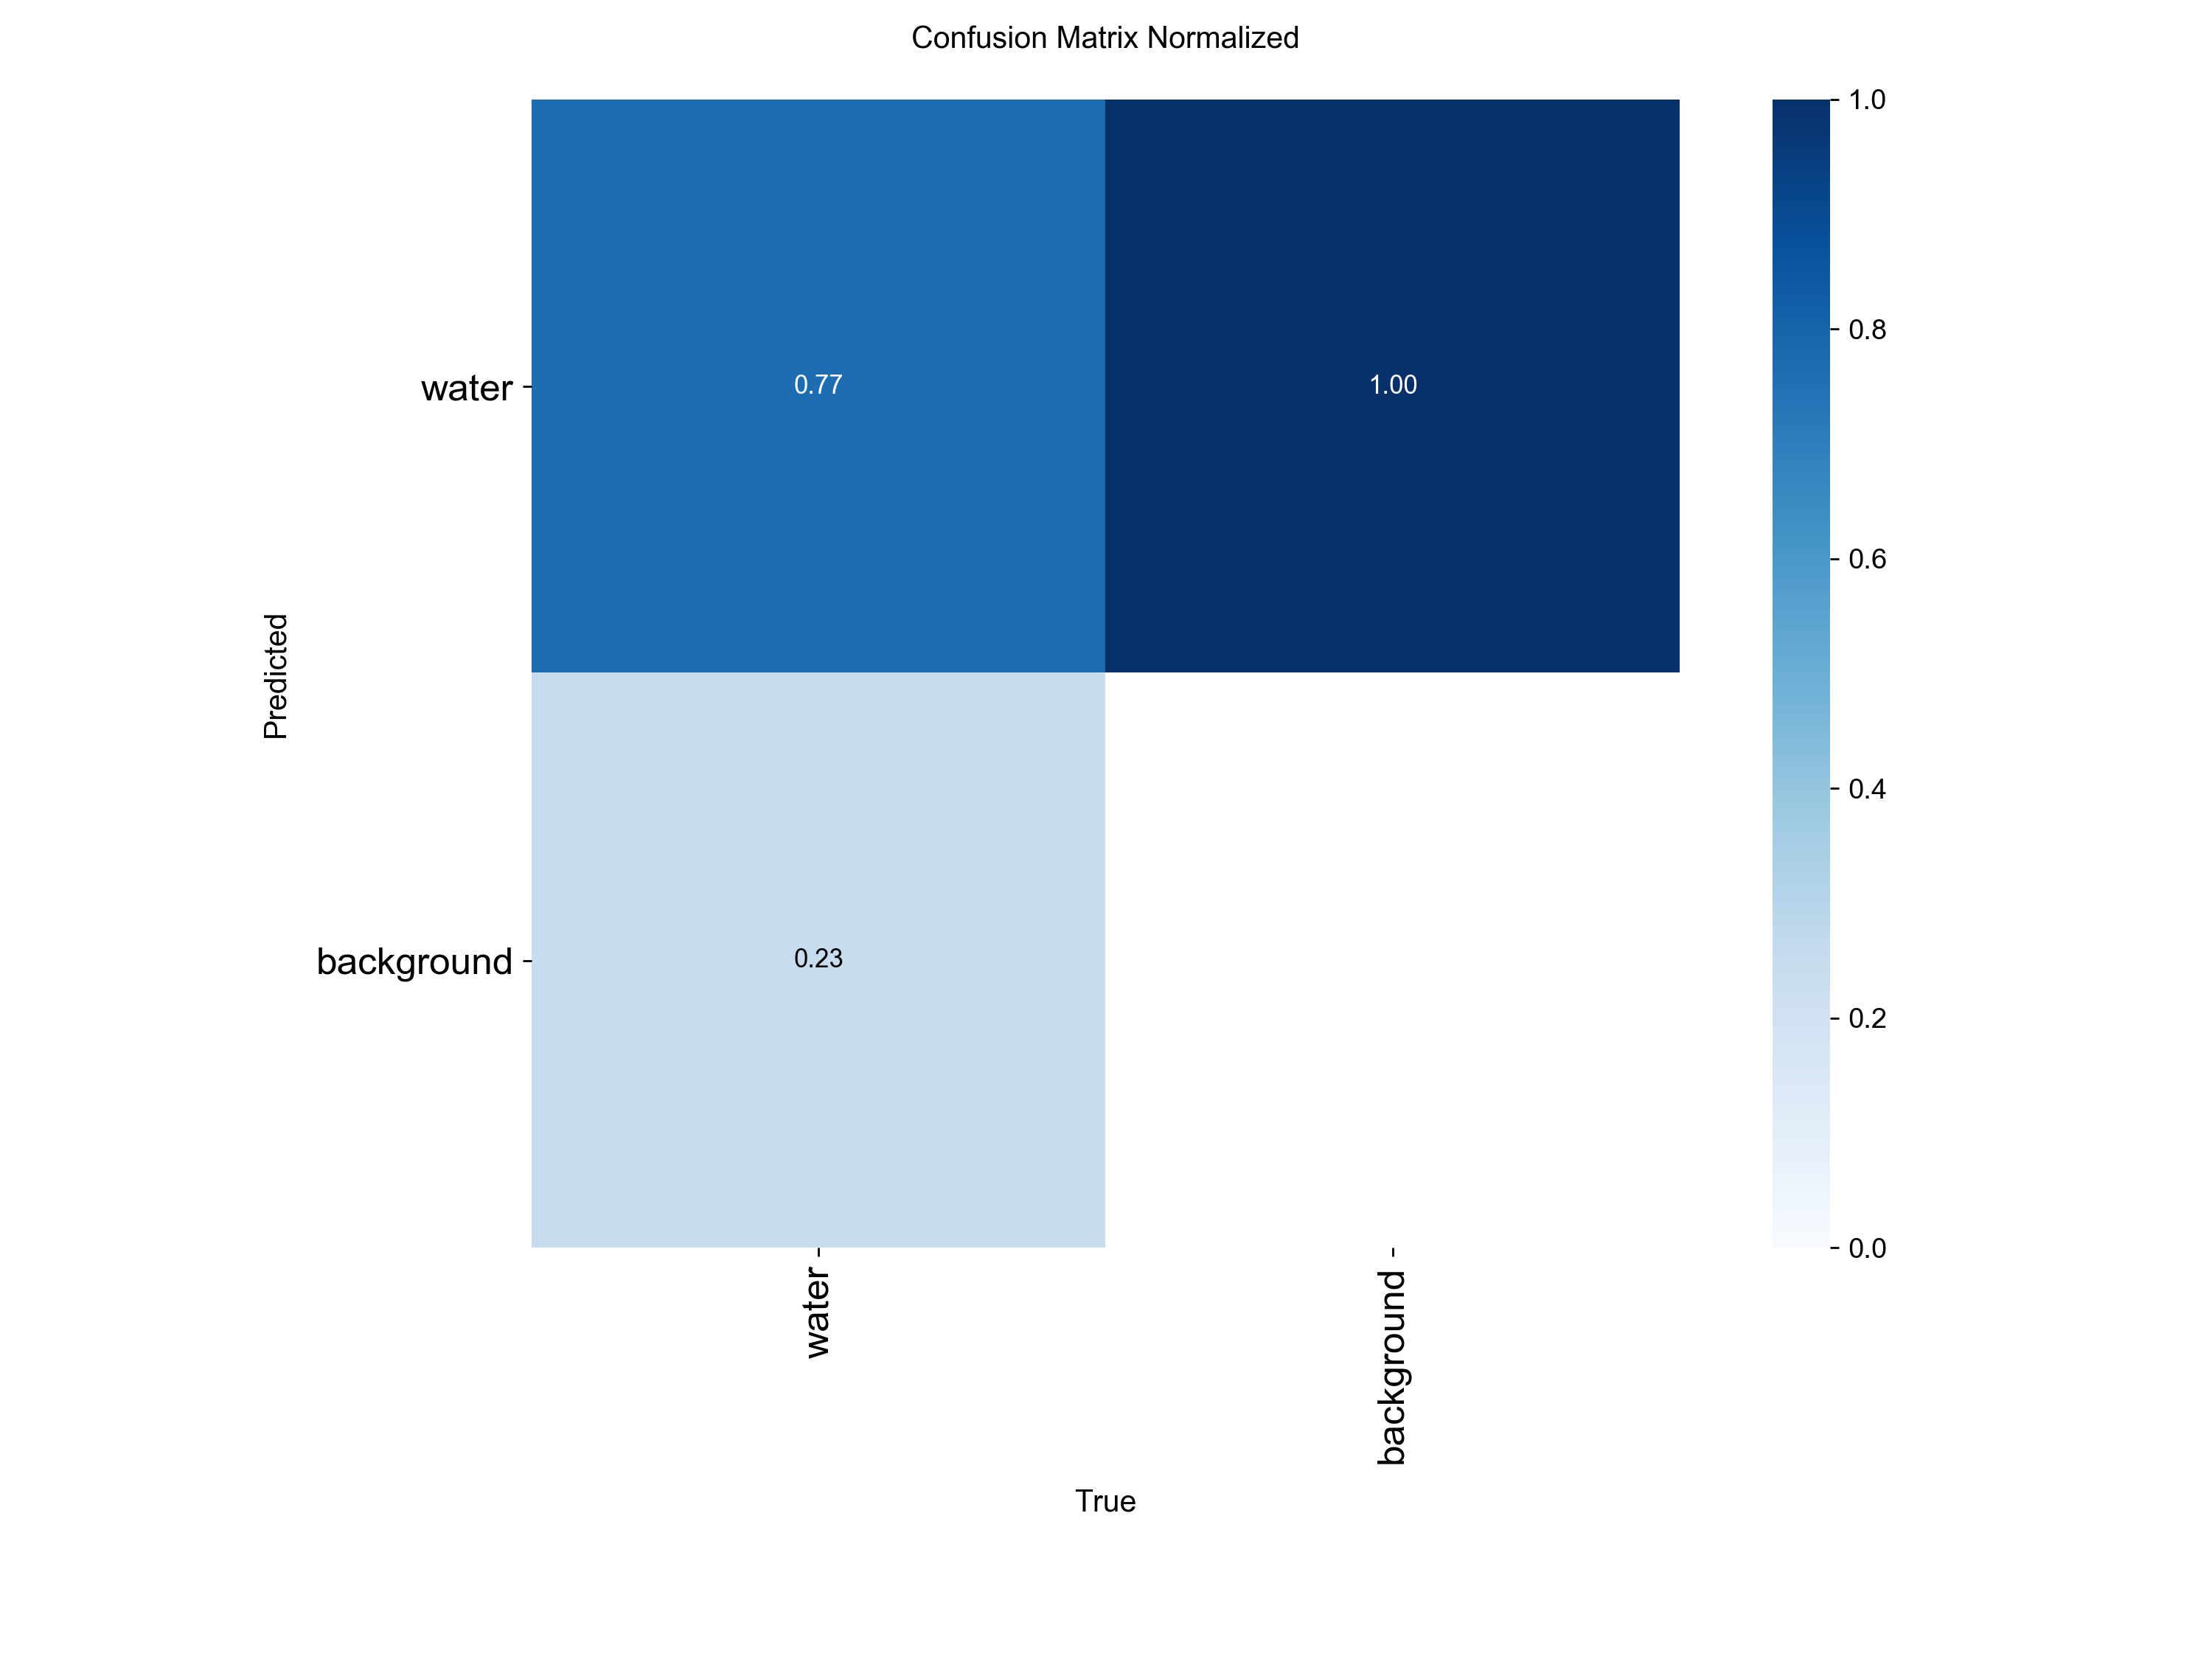

==================== val_batch0_pred.jpg


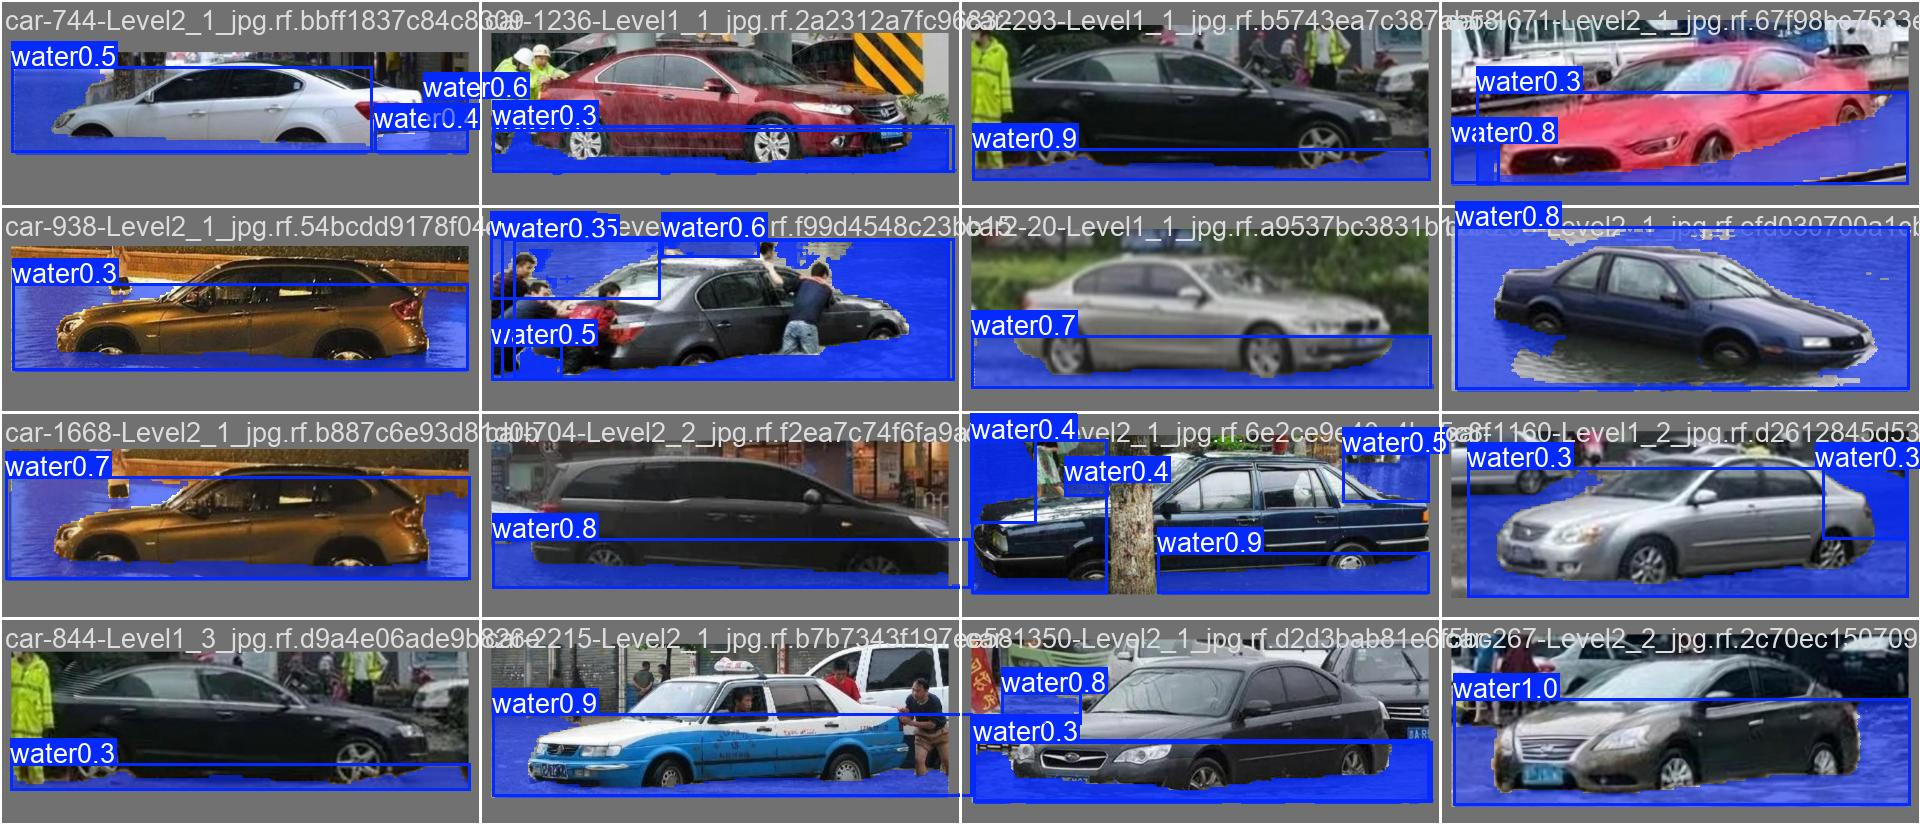

In [11]:
# 학습 곡선 / 혼동행렬 등 결과 이미지 확인
from IPython.display import Image, display
for f in ["results.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"]:
    p = SAVE_DIR / f
    if p.exists():
        print("=" * 20, f)
        display(Image(filename=str(p), width=900))

## 9. 추론 — 수면 마스크 시각화

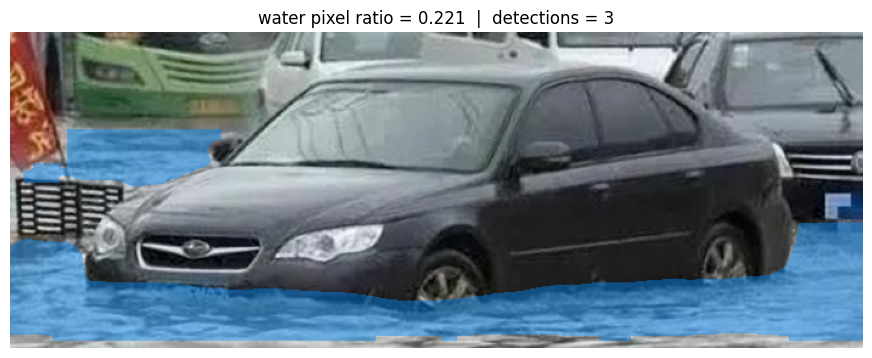

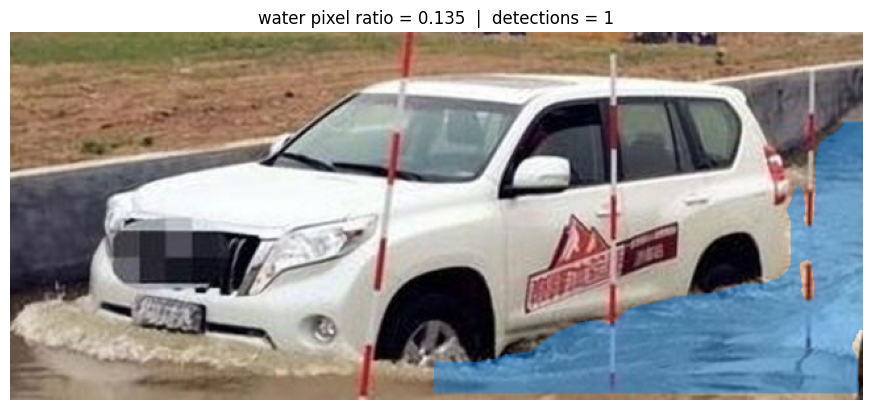

In [12]:
def predict_water(img_path, conf=0.25, show=True):
    '''단일 이미지 추론 → (원본, 통합 수면 마스크, 결과객체)'''
    r = best.predict(source=str(img_path), conf=conf, imgsz=CFG["IMGSZ"],
                     device=0 if torch.cuda.is_available() else "cpu", verbose=False)[0]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    water = np.zeros((h, w), dtype=np.uint8)
    if r.masks is not None:
        for m in r.masks.data.cpu().numpy():
            water |= (cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST) > 0.5).astype(np.uint8)

    if show:
        vis = img.copy()
        vis[water == 1] = (0.45 * np.array([0, 140, 255]) + 0.55 * vis[water == 1]).astype(np.uint8)
        ratio = water.mean()
        plt.figure(figsize=(11, 6))
        plt.imshow(vis); plt.axis("off")
        plt.title(f"water pixel ratio = {ratio:.3f}  |  detections = {0 if r.masks is None else len(r.masks)}")
        plt.show()
    return img, water, r


# 테스트 셋에서 무작위 2장
test_imgs = sorted((DST_ROOT / "images" / "test").glob("*.jpg"))
for f in random.sample(test_imgs, min(2, len(test_imgs))):
    predict_water(f)

## 10. 침수 파이프라인 연동 유틸

수면 마스크 자체보다 **"차량 바퀴가 얼마나 잠겼는가"** 가 최종 지표이므로,
바퀴 bbox와 수면 마스크를 교차시켜 침수율을 계산하는 함수를 함께 둡니다.
`wheel_boxes`는 2단계(바퀴 검출) 모델의 출력 `[x1, y1, x2, y2]` 리스트를 그대로 넣으면 됩니다.

In [13]:
def water_line_y(water_mask, x_range=None):
    '''지정 x구간에서 수면의 최상단 y좌표(픽셀). 물이 없으면 None.'''
    m = water_mask if x_range is None else water_mask[:, x_range[0]:x_range[1]]
    ys = np.where(m.any(axis=1))[0]
    return int(ys.min()) if len(ys) else None


def wheel_submersion(water_mask, wheel_box):
    '''바퀴 bbox 내 수면 픽셀 비율 + 수면선 기준 잠김 높이 비율.'''
    x1, y1, x2, y2 = [int(v) for v in wheel_box]
    h, w = water_mask.shape
    x1, x2 = max(0, x1), min(w, x2)
    y1, y2 = max(0, y1), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return {"pixel_ratio": 0.0, "height_ratio": 0.0, "water_y": None}

    roi = water_mask[y1:y2, x1:x2]
    pixel_ratio = float(roi.mean())

    wy = water_line_y(water_mask, (x1, x2))
    height_ratio = 0.0 if wy is None else float(np.clip((y2 - max(wy, y1)) / (y2 - y1), 0, 1))
    return {"pixel_ratio": round(pixel_ratio, 4),
            "height_ratio": round(height_ratio, 4),
            "water_y": wy}


def level_from_ratio(height_ratio):
    '''바퀴 잠김 비율 → 침수 5단계(0~4). 임계값은 프로젝트 기준에 맞춰 조정하세요.'''
    if height_ratio < 0.05: return 0
    if height_ratio < 0.25: return 1   # 타이어 하단
    if height_ratio < 0.50: return 2   # 휠 림 하단
    if height_ratio < 0.75: return 3   # 휠 림 상단
    return 4                            # 타이어 완전 침수

# --- 사용 예시 (바퀴 검출 모델의 bbox를 넣어 사용) ---
demo = test_imgs[0] if test_imgs else None
if demo:
    img, water, r = predict_water(demo, show=False)
    h, w = water.shape
    dummy_wheel = [int(w * 0.35), int(h * 0.55), int(w * 0.50), int(h * 0.80)]  # 예시용 임시 bbox
    info = wheel_submersion(water, dummy_wheel)
    print(demo.name, info, "→ Level", level_from_ratio(info["height_ratio"]))

C2VtYH_jpg.rf.46970ab88100464c16e1fb06abd0e91b.jpg {'pixel_ratio': 0.2048, 'height_ratio': 0.2375, 'water_y': 474} → Level 1


### 10-1. 파일명 레벨 라벨로 교차 검증

파일명이 `car-1008-Level2_1.jpg` 형태라 이미 침수 레벨이 들어있습니다.
**레벨이 올라갈수록 수면 픽셀 비율이 단조 증가**하면 모델이 물을 제대로 잡고 있다는 근거가 됩니다.
발표 자료의 정량 검증 항목으로 그대로 쓸 수 있습니다.

In [14]:
import re

def level_consistency_check(split="test"):
    imgs = sorted((DST_ROOT / "images" / split).glob("*.jpg"))
    buckets = defaultdict(list)
    for f in imgs:
        m = re.search(r"Level(\d)", f.name)
        if not m:
            continue
        _, water, _ = predict_water(f, show=False)
        buckets[int(m.group(1))].append(float(water.mean()))

    if not buckets:
        print("파일명에 Level 표기가 있는 이미지가 없습니다."); return None

    rows = []
    for lv in sorted(buckets):
        v = np.array(buckets[lv])
        rows.append((lv, len(v), v.mean(), v.std()))
        print(f"Level {lv} | n={len(v):3d} | 수면비율 평균 {v.mean():.4f} (std {v.std():.4f})")

    means = [r[2] for r in rows]
    mono = all(means[i] <= means[i + 1] for i in range(len(means) - 1))
    print("\n단조 증가:", "YES — 모델이 레벨 차이를 반영하고 있습니다"
          if mono else "NO — 임계값/라벨 재점검 필요")
    return rows

rows = level_consistency_check("test")

Level 1 | n= 19 | 수면비율 평균 0.1786 (std 0.0488)
Level 2 | n= 26 | 수면비율 평균 0.2388 (std 0.1437)

단조 증가: YES — 모델이 레벨 차이를 반영하고 있습니다


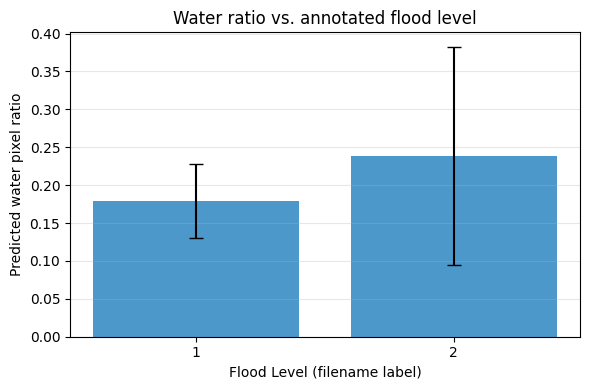

In [15]:
# 위 결과를 막대그래프로 (발표 슬라이드용)
if rows:
    lv = [r[0] for r in rows]; mu = [r[2] for r in rows]; sd = [r[3] for r in rows]
    plt.figure(figsize=(6, 4))
    plt.bar(lv, mu, yerr=sd, capsize=5, color="#2E86C1", alpha=0.85)
    plt.xlabel("Flood Level (filename label)"); plt.ylabel("Predicted water pixel ratio")
    plt.title("Water ratio vs. annotated flood level"); plt.xticks(lv)
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## 11. 모델 저장 / 내보내기

In [16]:
EXPORT_DIR = Path(CFG["RUN_PROJECT"]) / "exported"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

final_pt = EXPORT_DIR / "water_seg_best.pt"
shutil.copy2(BEST_PT, final_pt)
print("PT 저장:", final_pt)

# 실시간 추론이 필요하면 ONNX로 내보내기 (선택)
# onnx_path = best.export(format="onnx", imgsz=CFG["IMGSZ"], simplify=True, opset=12)
# print("ONNX:", onnx_path)

PT 저장: C:\Project\PythonProject\PyTorch001\runs_water\exported\water_seg_best.pt
